The purpose of this file is to be an organized ipynb file of all of the work I did for milestone 1 including problem formulation, data acquisition 1, creating my database, and data exploration. In order to see exactly what I did you can explore the raw_work folder but for clarity this fiile includes the most relevant and best work. The dairy folder has detailed descriptions of problem formulation, data acquisition, database management, and data exploration while the raw_work folder contains the corresponding ipynb files for each weeks work.

Problem Formation: For an overall summary, the initial premise of this project stemmed from my love for reading about individual stocks I am following. Each stock has a corresponding ticker on stock exchanges where you can buy and sell the security. For example, NVIDIA's ticker is "NVDA". I have noticed over the years that publishers and journalists that write about tickers have been terribly wrong when it comes to interpreting news about a company or explaining current events. This is in part because anyone can write articles and part because there is rampant corruption in our markets and a lot of these news organizations exist just to creative a narrative to extract money from the everday average person. There is so much corruption in the markets that I want to have a tool that can combat one of the many methods of manipulation. As a result, I want a model that can classify authors and organizations based on how well they characterize these stocks so the everyday person can understand if they are reading valuable information or completely skewed perspectives. This is going to be done by taking all the article headlines a given author or organization has written, perform a sentiment analysis on the headline, and compare the sentiment to the performance of the stock after the article was written in time intervals to see if the characterization is valid. The specific time intervals will need tested and so will the classification system but I am confident that this is something that can be modeled. 

Data Acquisition: There are three primary sources of data that I need for this project and as we have discussed in class the purpose of milestone 1 is only to contain the raw data. The stock ticker performance and sentiment analysis is something that I am going to have to create in the future. The raw data that I started with came from the link:  https://www.kaggle.com/datasets/elsabetyemane/financial-news-and-stock-price-integration-dataset. There is an in depth review of the raw data in the Data_Dictionary.pdf in this repo that is necessary for understanding what exactly im doing.

In [3]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("raw_analyst_ratings.csv")

In [ ]:
data.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,21991,"UBS Maintains Buy on Adobe, Raises Price Targe...",https://www.benzinga.com/news/20/06/16202690/u...,Benzinga Newsdesk,2020-06-08 10:57:41-04:00,ADBE
1,21992,Stocks That Hit 52-Week Highs On Thursday,https://www.benzinga.com/news/20/06/16180865/s...,Benzinga Insights,2020-06-04 10:48:11-04:00,ADBE
2,21993,Shares of several companies in the broader tec...,https://www.benzinga.com/wiim/20/05/16116988/s...,Benzinga Newsdesk,2020-05-27 10:24:38-04:00,ADBE
3,21994,Stocks That Hit 52-Week Highs On Tuesday,https://www.benzinga.com/news/20/05/16106805/s...,Benzinga Insights,2020-05-26 10:32:14-04:00,ADBE
4,21995,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/05/16075931/s...,Benzinga Newsdesk,2020-05-20 10:19:31-04:00,ADBE


A month ago during the initial stages of the project the raw data contained an index, headline, url, publisher, published date and stock ticker

In [7]:
con = sqlite3.connect("ratings.db")
cur = con.cursor()
cur.execute("""
            CREATE TABLE IF NOT EXISTS articles(
            article_id INTEGER PRIMARY KEY,
            headline TEXT,
            url TEXT,
            publisher TEXT,
            published_at TEXT,
            ticker TEXT,
            Headline_Class TEXT)
            """)

cur.execute("""
            CREATE TABLE IF NOT EXISTS returns(
            article_id INTEGER PRIMARY KEY,
            return_7d REAL,
            return_30d REAL,
            return_6m0 REAL,
            price TEXT,
            FOREIGN KEY(article_id) REFERENCES articles(article_id))
            """)

cur.execute("""
            CREATE TABLE IF NOT EXISTS sentiment(
            article_id INTEGER PRIMARY KEY,
            sentiment_score REAL,
            sentiment_label REAL,
            method TEXT,
            FOREIGN KEY(article_id) REFERENCES articles(article_id))
            """)




I also created my empty database for future analysis. Initially I did not have the headline_class variable but I will discuss why it was added later. It is also important to note that the time intervals in the returns table are not finalized and will be subject to change. There is also a diagram of this database included in the repo for a more clear understanding.

On 2/5/2026 we went over the current state of the project and we talked about what the actual goal is. My data
contains rows consisting of the headline of the article, the publisher, the date it was published, and the stock ticker. 
The goal for this project is to investigate the stocks performance after the article published date and compare results
to the sentiment behind the headline to classify the publisher. After we spoke we decided it would be beneficial to add a column that semi accurately classifies the headlines as a prediction, movement, or just general news because we noted how
a vast majority of articles in this dataset tend to be just objective "on this date the price was x" which may need to be filtered out for actual training because this has no weighting on how good the publisher is unless they are objetively lying about the stock price but thats a very very small edge case.

The goal for this next code segment is to create a categories column that sorts the headline into opinion, price movement, forward looking and general news. This may be subject to change but all im doing is checking for keywords in the headline string and categorizing if the string contains the keyword.


In [8]:
# The goal is to classify each article with at least an 80% accuracy to significantly reduce the bloat the model will have to deal with
# For classifying publishers we only really want analysis or predictions to train on their ability to actually write and present factual data.
Analysis = [
    "upgrade", "upgraded", "upgrades", "downgrade", "downgraded", "downgrades",
    "initiates", "initiated", "rating", "ratings", "rated", "price target",
    "raises target", "cuts target", "pt", "buy", "sell", "hold"
]

Movement = [
    "shares", "stock", "up", "down", "rises", "falls",
    "gains", "drops", "surges", "plunges", "climbs",
    "tumbles", "slips", "higher", "lower", "plunge", "plunged",
    "fell", "falling", "slip", "slipped", "tumble", "rise'"
]

Prediction = [
    "expects", "expected", "forecast", "outlook",
    "guidance", "projects", "projected", "could",
    "may", "might", "likely", "unlikely", "project", "predict",
    "could"
]

In [ ]:
# I made a function that checks if any of the words above are found in the headline string for each row in the data set
def classifyHeadline(headline):
    if pd.isna(headline):
        return "No Headline"

    myHeadline = str(headline).lower()

    for word in Analysis:
        if word in myHeadline:
            return "Analysis"

    for word in Movement:
        if word in myHeadline:
            return "Movement"

    for word in Prediction:
        if word in myHeadline:
            return "Prediction"
        
    return "General"

In [10]:
data["Headline Class"] = data["headline"].apply(classifyHeadline)

print(data["Headline Class"].value_counts())

Headline Class
General       48544
Movement      28957
Analysis      25965
Prediction     4339
Name: count, dtype: int64


In [ ]:
# Checking results
data.groupby("Headline Class").head(5)[
    ["Headline Class", "headline"]
]

,Headline Class,headline
0,Analysis,"UBS Maintains Buy on Adobe, Raises Price Targe..."
1,Movement,Stocks That Hit 52-Week Highs On Thursday
2,Movement,Shares of several companies in the broader tec...
3,Movement,Stocks That Hit 52-Week Highs On Tuesday
4,Analysis,Shares of several technology companies are tra...
5,Analysis,"Benzinga's Top Upgrades, Downgrades For May 14..."
6,Analysis,"DZ Bank Downgrades Adobe to Hold, Announces $3..."
7,Movement,Shares of several technology companies are tra...
8,General,"'Fast Money' Traders Answer Questions On Uber,..."
9,Analysis,"BMO Capital Maintains Outperform on Adobe, Rai..."


The rest of the code is more data exploration in both python and sql

In [12]:
data.head()

,Unnamed: 0,headline,url,publisher,date,stock,Headline Class
0,21991,"UBS Maintains Buy on Adobe, Raises Price Targe...",https://www.benzinga.com/news/20/06/16202690/u...,Benzinga Newsdesk,2020-06-08 10:57:41-04:00,ADBE,Analysis
1,21992,Stocks That Hit 52-Week Highs On Thursday,https://www.benzinga.com/news/20/06/16180865/s...,Benzinga Insights,2020-06-04 10:48:11-04:00,ADBE,Movement
2,21993,Shares of several companies in the broader tec...,https://www.benzinga.com/wiim/20/05/16116988/s...,Benzinga Newsdesk,2020-05-27 10:24:38-04:00,ADBE,Movement
3,21994,Stocks That Hit 52-Week Highs On Tuesday,https://www.benzinga.com/news/20/05/16106805/s...,Benzinga Insights,2020-05-26 10:32:14-04:00,ADBE,Movement
4,21995,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/05/16075931/s...,Benzinga Newsdesk,2020-05-20 10:19:31-04:00,ADBE,Analysis


In [ ]:
data.info() # index column is an int datatype and the rest are objects (strings)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107805 entries, 0 to 107804
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Unnamed: 0      107805 non-null  int64 
 1   headline        107805 non-null  object
 2   url             107805 non-null  object
 3   publisher       107805 non-null  object
 4   date            107805 non-null  object
 5   stock           107805 non-null  object
 6   Headline Class  107805 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.8+ MB


In [ ]:
data.describe() #The only int is an index so the mean, std, etc do not have meaning

,Unnamed: 0
count,1.078050e+05
mean,6.428957e+05
std,3.850003e+05
min,2.199100e+04
25%,2.651510e+05
50%,7.094280e+05
75%,8.972850e+05
max,1.411295e+06


In [18]:
data.isnull()

,Unnamed: 0,headline,url,publisher,date,stock,Headline Class
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
107800,False,False,False,False,False,False,False
107801,False,False,False,False,False,False,False
107802,False,False,False,False,False,False,False
107803,False,False,False,False,False,False,False


In [ ]:
data.isnull().any() # No missing values in any columns in the dataset

Unnamed: 0        False
headline          False
url               False
publisher         False
date              False
stock             False
Headline Class    False
dtype: bool

In [21]:
# Making raw columns match what I made in the db
data = data.rename(columns={
    "date": "published_at",
    "stock": "ticker",
    "Headline Class": "Headline_Class",
    "Unnamed: 0": "article_id"
})
data.head()

,article_id,headline,url,publisher,published_at,ticker,Headline_Class
0,21991,"UBS Maintains Buy on Adobe, Raises Price Targe...",https://www.benzinga.com/news/20/06/16202690/u...,Benzinga Newsdesk,2020-06-08 10:57:41-04:00,ADBE,Analysis
1,21992,Stocks That Hit 52-Week Highs On Thursday,https://www.benzinga.com/news/20/06/16180865/s...,Benzinga Insights,2020-06-04 10:48:11-04:00,ADBE,Movement
2,21993,Shares of several companies in the broader tec...,https://www.benzinga.com/wiim/20/05/16116988/s...,Benzinga Newsdesk,2020-05-27 10:24:38-04:00,ADBE,Movement
3,21994,Stocks That Hit 52-Week Highs On Tuesday,https://www.benzinga.com/news/20/05/16106805/s...,Benzinga Insights,2020-05-26 10:32:14-04:00,ADBE,Movement
4,21995,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/05/16075931/s...,Benzinga Newsdesk,2020-05-20 10:19:31-04:00,ADBE,Analysis


In [22]:
data.to_csv("raw_data_and_headline_classification.csv", index = False)

In [23]:
# Actually put my data in the table
data.to_sql("articles", con, if_exists="append", index=False)
con.commit()

In [ ]:
pd.read_sql("SELECT COUNT(*) AS n_rows FROM articles;", con) # all the rows are there

,n_rows
0,107805


In [25]:
pd.read_sql("SELECT * FROM articles LIMIT 5;", con) # equivalent of .head()


,article_id,headline,url,publisher,published_at,ticker,Headline_Class
0,21991,"UBS Maintains Buy on Adobe, Raises Price Targe...",https://www.benzinga.com/news/20/06/16202690/u...,Benzinga Newsdesk,2020-06-08 10:57:41-04:00,ADBE,Analysis
1,21992,Stocks That Hit 52-Week Highs On Thursday,https://www.benzinga.com/news/20/06/16180865/s...,Benzinga Insights,2020-06-04 10:48:11-04:00,ADBE,Movement
2,21993,Shares of several companies in the broader tec...,https://www.benzinga.com/wiim/20/05/16116988/s...,Benzinga Newsdesk,2020-05-27 10:24:38-04:00,ADBE,Movement
3,21994,Stocks That Hit 52-Week Highs On Tuesday,https://www.benzinga.com/news/20/05/16106805/s...,Benzinga Insights,2020-05-26 10:32:14-04:00,ADBE,Movement
4,21995,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/05/16075931/s...,Benzinga Newsdesk,2020-05-20 10:19:31-04:00,ADBE,Analysis


In [26]:
cur.execute("SELECT COUNT(*) FROM articles;")
print(cur.fetchone())

(107805,)


In [ ]:
# Are the keys unique? Yes
cur.execute("""
            SELECT COUNT(*) AS n_rows,
            COUNT(DISTINCT article_id) AS n_distinct_ids
            FROM articles;
            """)
print(cur.fetchone())

(107805, 107805)


In [28]:
data.shape

(107805, 7)

In [29]:
data.columns

Index(['article_id', 'headline', 'url', 'publisher', 'published_at', 'ticker',
       'Headline_Class'],
      dtype='object')

In [30]:
data.dtypes

article_id         int64
headline          object
url               object
publisher         object
published_at      object
ticker            object
Headline_Class    object
dtype: object

In [31]:
simple_random_sample = data.sample(n=50, random_state=42)
simple_random_sample.shape

(50, 7)

In [ ]:
data[data.duplicated()] # Still no missing data so everything looks good

,article_id,headline,url,publisher,published_at,ticker,Headline_Class


In [33]:
print(data.isna().sum())

article_id        0
headline          0
url               0
publisher         0
published_at      0
ticker            0
Headline_Class    0
dtype: int64


In [34]:
con.close()

The goal with data exploration is to analyze feature distributions, examine feature-feature relationships, use correlation matrices and heatmaps, and explore high-dimensional structure. I think this will be interesting to do with my raw data because it does not include sentiment scores or yFinance data on the change in stock price so the list of features is currently the headline, url, publisher, published date, ticker, and the headline class column I added. Most of the data is categorical so I will do what I can with the raw data. The most interesting features to explore were the ticker, publisher, and headline_class relationships

<function matplotlib.pyplot.show(close=None, block=None)>

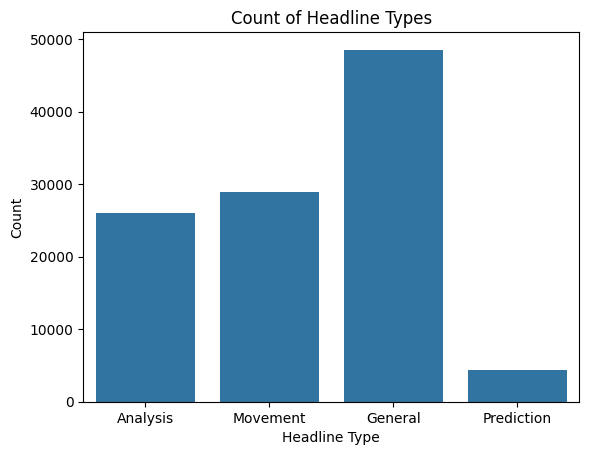

In [35]:
sns.countplot(data=data, x="Headline_Class")
plt.title("Count of Headline Types")
plt.xlabel("Headline Type")
plt.ylabel("Count")
plt.show

You can see in the plot above our discussion to classify the headline type was very important because otherwise I would be feeding the model so many useless movement and general articles that do not offer any new information.

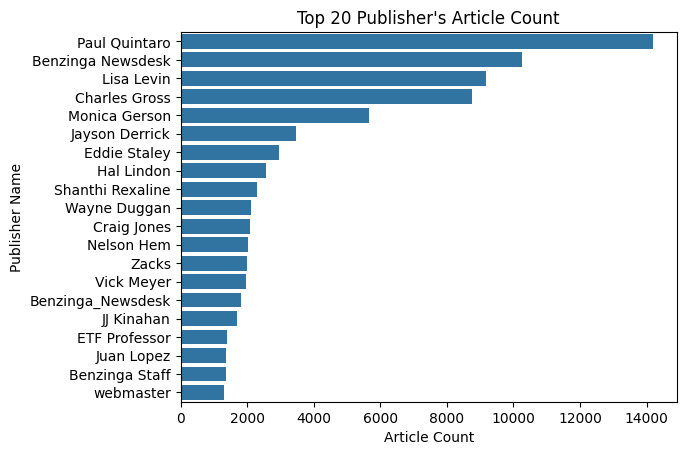

In [37]:
prominent_publishers = data["publisher"].value_counts().head(20)
publisher_count = prominent_publishers.values
publisher_name = prominent_publishers.index
sns.barplot(x=publisher_count, y=publisher_name)
plt.title("Top 20 Publisher's Article Count")
plt.xlabel("Article Count")
plt.ylabel("Publisher Name")
plt.show()

The figure above shows the top 20 publishers in terms of amount of articles written in the data set. This may be important later for my classification model because I will need to set a sample size limit to even consider an author for classification. 

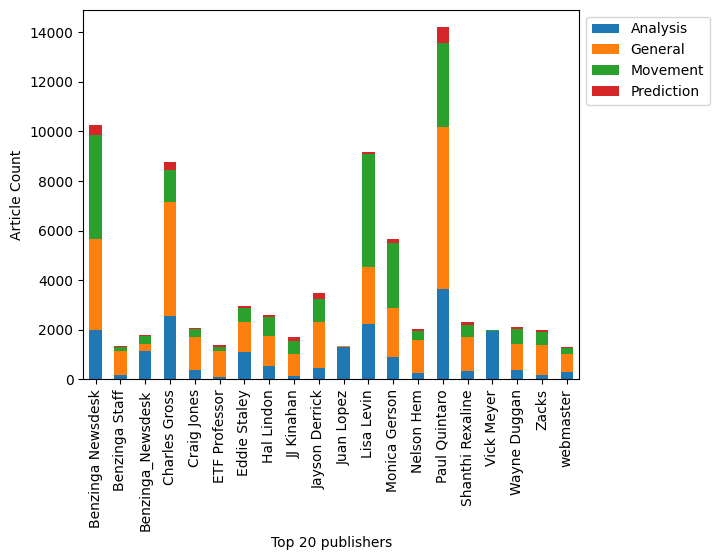

In [38]:
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html
top_publishers = data['publisher'].value_counts().head(20).index
filtered_publishers = data[data['publisher'].isin(top_publishers)] # Get only the data that is the top 20 publishers
plot_data = pd.crosstab(filtered_publishers['publisher'], filtered_publishers['Headline_Class'])
plot_data.plot(kind="bar", stacked=True)
plt.xlabel("Top 20 publishers")
plt.ylabel("Article Count")
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")


The plot above shows the distibution of article type by the top 20 publishers. Based on the raw counts this is expected with general and movement dominating the article type while analysis and prediction take on a much smaller subset. Two interesting anomalies are Benzinga Newsdesk and Lisa Levin reporting more movement than general articles suggesting they post often about what is happening to the price of tickers themselves rather than things that may be impacting the price. 

In [42]:
data['headline_length'] = data['headline'].str.len()
data['headline_length'].describe()

count    107805.000000
mean         75.714151
std          42.931589
min           5.000000
25%          48.000000
50%          65.000000
75%          87.000000
max         458.000000
Name: headline_length, dtype: float64

Due to the nature of the data there are not a lot of valuable descriptive statistics. However, for sentiment analysis down the line I think it is really beneficial to have data on the headline length to analyze the impacts on sentiment scores for model tuning.

<Axes: xlabel='Headline_Class', ylabel='headline_length'>

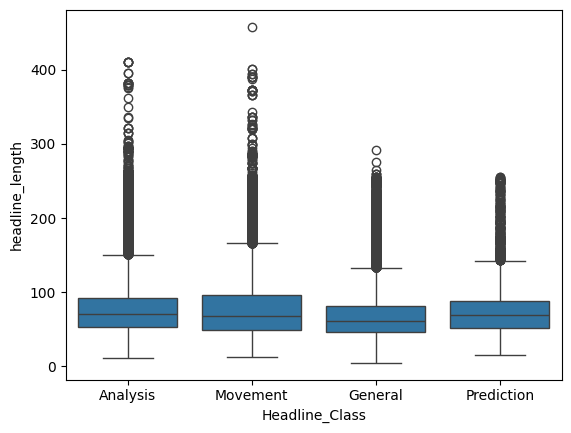

In [43]:
sns.boxplot(data=data, x='Headline_Class', y='headline_length')

The boxplot showing the relationship between the type of headline and the length of the headline indicates that the type doesnt determine the length. However I will note that my model will only include analysis and prediction headline types and the excess of outliers for analysis compared to prediction could influence sentiment scores in an unintended way that will need to be accounted for.